# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [76]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

## 2. Datos

In [77]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col="laptop_ID")

### 2.1 Exploración de los datos

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [79]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [80]:
df.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [81]:
df.describe()

,Inches,Price_in_euros
count,912.000000,912.000000
mean,14.981579,1111.724090
std,1.436719,687.959172
min,10.100000,174.000000
25%,14.000000,589.000000
50%,15.600000,978.000000
75%,15.600000,1483.942500
max,18.400000,6099.000000


### 2.3 Definir X e y

In [82]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 11)

In [83]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [85]:
X_train

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg
...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,1.94kg
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg
770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.18kg


In [86]:
y_train

laptop_ID
1118    2899.00
153     1249.26
275     1958.90
1100    1030.99
131     1396.00
         ...   
578      389.00
996      549.00
770     1859.00
407      306.00
418     1943.00
Name: Price_in_euros, Length: 729, dtype: float64

In [87]:
X_train["Weight_sin_kg"]= X_train["Weight"].str.replace("kg","").astype(float)
X_train["Ram_sin_GB"]= X_train["Ram"].str.replace("GB","").astype(int)

In [88]:
X_test["Weight_sin_kg"]= X_test["Weight"].str.replace("kg","").astype(float)
X_test["Ram_sin_GB"]= X_test["Ram"].str.replace("GB","").astype(int)

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [89]:
target="Price_in_euros"

<Axes: >

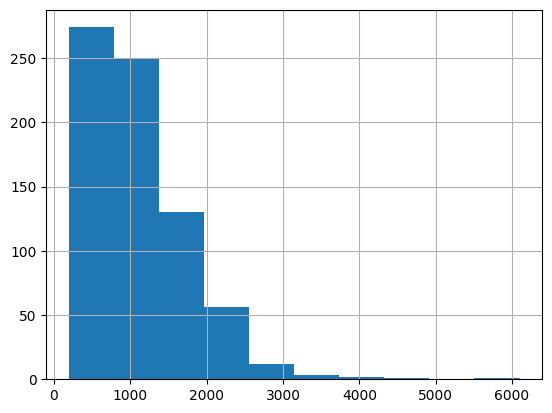

In [90]:
y_train.hist()

In [91]:
X_train.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Weight_sin_kg,Ram_sin_GB
laptop_ID,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg,3.00,8
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg,2.56,16
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg,1.37,8
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg,1.54,4
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg,2.80,16


In [92]:
X_train["Memory"].value_counts()

Memory
256GB SSD                 226
1TB HDD                   122
500GB HDD                  80
512GB SSD                  62
128GB SSD +  1TB HDD       56
128GB SSD                  45
256GB SSD +  1TB HDD       43
32GB Flash Storage         23
1TB SSD                     8
64GB Flash Storage          8
256GB Flash Storage         7
512GB SSD +  1TB HDD        6
256GB SSD +  2TB HDD        6
2TB HDD                     6
16GB Flash Storage          4
128GB Flash Storage         4
1.0TB Hybrid                3
32GB SSD                    3
512GB SSD +  2TB HDD        2
180GB SSD                   2
8GB SSD                     1
1TB SSD +  1TB HDD          1
128GB HDD                   1
240GB SSD                   1
512GB Flash Storage         1
512GB SSD +  512GB SSD      1
1TB HDD +  1TB HDD          1
1.0TB HDD                   1
256GB SSD +  256GB SSD      1
16GB SSD                    1
128GB SSD +  2TB HDD        1
508GB Hybrid                1
64GB SSD                    1
Nam

In [93]:
import re

In [94]:
import re

def parse_memory(text):
    pattern = r'(\d+)\s*(GB|TB)\s*([A-Za-z ]+)'
    matches = re.findall(pattern, text, flags=re.IGNORECASE)

    result = {
        "SSD_GB": 0,
        "HDD_GB": 0,
        "FLASH_GB": 0
    }

    for size, unit, storage_type in matches:
        size = int(size)

        # Convertir TB a GB
        if unit.upper() == "TB":
            size *= 1024

        storage_type = storage_type.upper()

        if "SSD" in storage_type:
            result["SSD_GB"] += size
        elif "HDD" in storage_type:
            result["HDD_GB"] += size
        elif "FLASH" in storage_type:
            result["FLASH_GB"] += size

    return result


In [95]:
df_memoria = X_train["Memory"].apply(parse_memory).apply(pd.Series)
df_memoria_test = X_test["Memory"].apply(parse_memory).apply(pd.Series)

In [96]:
df_memoria

,SSD_GB,HDD_GB,FLASH_GB
laptop_ID,,,
1118,0,1024,0
153,512,0,0
275,512,0,0
1100,0,500,0
131,256,2048,0
...,...,...,...
578,0,2048,0
996,256,0,0
770,256,0,0


In [97]:
X_train = pd.concat([X_train, df_memoria], axis=1)
X_test = pd.concat([X_test, df_memoria_test], axis=1)

In [98]:
X_train

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB
laptop_ID,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg,3.00,8,0,1024,0
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg,2.56,16,512,0,0
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg,1.37,8,512,0,0
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg,1.54,4,0,500,0
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg,2.80,16,256,2048,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,1.94kg,1.94,8,0,2048,0
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,2.20,6,256,0,0
770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.18kg,1.18,16,256,0,0


In [99]:
X_train = X_train.drop(columns=['Ram', 'Memory','Weight'])
X_test = X_test.drop(columns=['Ram', 'Memory','Weight'])

In [100]:
X_train.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu',
       'Gpu', 'OpSys', 'Weight_sin_kg', 'Ram_sin_GB', 'SSD_GB', 'HDD_GB',
       'FLASH_GB'],
      dtype='object')

In [101]:
X_train.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB
laptop_ID,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,AMD FirePro W6150M,Windows 7,3.00,8,0,1024,0
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,Nvidia GeForce GTX 1050,Windows 10,2.56,16,512,0,0
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,Intel Iris Graphics 550,macOS,1.37,8,512,0,0
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,Intel HD Graphics 520,Windows 7,1.54,4,0,500,0
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,AMD Radeon 530,Windows 10,2.80,16,256,2048,0


In [102]:


def parse_resolution(text):
    result = {
        "width": None,
        "height": None,
        "resolution_pixels": None,
        "is_ips": 0,
        "is_full_hd": 0
    }

    if isinstance(text, str):

        # Detectar IPS
        if "IPS" in text.upper():
            result["is_ips"] = 1

        # Detectar Full HD
        if "FULL HD" in text.upper():
            result["is_full_hd"] = 1

        # Extraer resolución tipo 1920x1080
        match = re.search(r'(\d+)\s*x\s*(\d+)', text)

        if match:
            width = int(match.group(1))
            height = int(match.group(2))

            result["width"] = width
            result["height"] = height
            result["resolution_pixels"] = width * height

    return result


In [103]:
df_resolution = X_train["ScreenResolution"].apply(parse_resolution).apply(pd.Series)

df_resolution.index = X_train.index

X_train = pd.concat([X_train, df_resolution], axis=1)

In [104]:
df_resolution_test = X_test["ScreenResolution"].apply(parse_resolution).apply(pd.Series)

df_resolution_test.index = X_test.index

X_test = pd.concat([X_test, df_resolution_test], axis=1)

In [105]:
X_train

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,resolution_pixels,is_ips,is_full_hd
laptop_ID,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,AMD FirePro W6150M,Windows 7,3.00,8,0,1024,0,1920,1080,2073600,1,1
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,Nvidia GeForce GTX 1050,Windows 10,2.56,16,512,0,0,1920,1080,2073600,0,1
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,Intel Iris Graphics 550,macOS,1.37,8,512,0,0,2560,1600,4096000,1,0
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,Intel HD Graphics 520,Windows 7,1.54,4,0,500,0,1920,1080,2073600,0,1
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,AMD Radeon 530,Windows 10,2.80,16,256,2048,0,1920,1080,2073600,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,Intel HD Graphics 405,Windows 10,1.94,8,0,2048,0,1366,768,1049088,0,0
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,AMD Radeon 530,Windows 10,2.20,6,256,0,0,1920,1080,2073600,0,1
770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,Intel HD Graphics 620,Windows 10,1.18,16,256,0,0,1920,1080,2073600,0,1


In [106]:
X_train = X_train.drop(columns=["ScreenResolution"])
X_test = X_test.drop(columns=["ScreenResolution"])

In [107]:
X_train

,Company,Product,TypeName,Inches,Cpu,Gpu,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,resolution_pixels,is_ips,is_full_hd
laptop_ID,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,Intel Core i7 6700HQ 2.6GHz,AMD FirePro W6150M,Windows 7,3.00,8,0,1024,0,1920,1080,2073600,1,1
153,Dell,Inspiron 5577,Gaming,15.6,Intel Core i7 7700HQ 2.8GHz,Nvidia GeForce GTX 1050,Windows 10,2.56,16,512,0,0,1920,1080,2073600,0,1
275,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.9GHz,Intel Iris Graphics 550,macOS,1.37,8,512,0,0,2560,1600,4096000,1,0
1100,HP,EliteBook 840,Notebook,14.0,Intel Core i5 6200U 2.3GHz,Intel HD Graphics 520,Windows 7,1.54,4,0,500,0,1920,1080,2073600,0,1
131,Dell,Inspiron 5770,Notebook,17.3,Intel Core i7 8550U 1.8GHz,AMD Radeon 530,Windows 10,2.80,16,256,2048,0,1920,1080,2073600,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,Intel Pentium Quad Core N3710 1.6GHz,Intel HD Graphics 405,Windows 10,1.94,8,0,2048,0,1366,768,1049088,0,0
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,AMD A12-Series 9720P 3.6GHz,AMD Radeon 530,Windows 10,2.20,6,256,0,0,1920,1080,2073600,0,1
770,Dell,Latitude 7280,Ultrabook,12.5,Intel Core i7 7600U 2.8GHz,Intel HD Graphics 620,Windows 10,1.18,16,256,0,0,1920,1080,2073600,0,1


In [108]:
def parse_cpu(text):
    result = {
        "cpu_brand": None,
        "cpu_family": None,
        "cpu_generation": None,
        "cpu_model_number": None,
        "cpu_frequency_GHz": None
    }

    if not isinstance(text, str):
        return result

    text_upper = text.upper()

    # 🔹 Marca
    if "INTEL" in text_upper:
        result["cpu_brand"] = "Intel"
    elif "AMD" in text_upper:
        result["cpu_brand"] = "AMD"

    # 🔹 Familia (Intel i3/i5/i7/i9)
    family_match = re.search(r'(I[3579])', text_upper)
    if family_match:
        result["cpu_family"] = family_match.group(1)

    # 🔹 Frecuencia (ej 2.6GHz)
    freq_match = re.search(r'(\d+\.?\d*)\s*GHZ', text_upper)
    if freq_match:
        result["cpu_frequency_GHz"] = float(freq_match.group(1))

    # 🔹 Modelo numérico (ej 6700HQ)
    model_match = re.search(r'(\d{4,5})', text_upper)
    if model_match:
        model_number = model_match.group(1)
        result["cpu_model_number"] = int(model_number)

        # Para Intel: primera cifra = generación
        result["cpu_generation"] = int(model_number[0])

    return result

In [109]:
df_cpu = X_train["Cpu"].apply(parse_cpu).apply(pd.Series)
df_cpu.index = X_train.index

X_train = pd.concat([X_train, df_cpu], axis=1)

In [110]:
df_cpu_test = X_test["Cpu"].apply(parse_cpu).apply(pd.Series)
df_cpu_test.index = X_test.index

X_test = pd.concat([X_test, df_cpu_test], axis=1)

In [111]:
X_train

,Company,Product,TypeName,Inches,Cpu,Gpu,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,...,width,height,resolution_pixels,is_ips,is_full_hd,cpu_brand,cpu_family,cpu_generation,cpu_model_number,cpu_frequency_GHz
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,Intel Core i7 6700HQ 2.6GHz,AMD FirePro W6150M,Windows 7,3.00,8,0,...,1920,1080,2073600,1,1,Intel,I7,6.0,6700.0,2.6
153,Dell,Inspiron 5577,Gaming,15.6,Intel Core i7 7700HQ 2.8GHz,Nvidia GeForce GTX 1050,Windows 10,2.56,16,512,...,1920,1080,2073600,0,1,Intel,I7,7.0,7700.0,2.8
275,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.9GHz,Intel Iris Graphics 550,macOS,1.37,8,512,...,2560,1600,4096000,1,0,Intel,I5,NaN,NaN,2.9
1100,HP,EliteBook 840,Notebook,14.0,Intel Core i5 6200U 2.3GHz,Intel HD Graphics 520,Windows 7,1.54,4,0,...,1920,1080,2073600,0,1,Intel,I5,6.0,6200.0,2.3
131,Dell,Inspiron 5770,Notebook,17.3,Intel Core i7 8550U 1.8GHz,AMD Radeon 530,Windows 10,2.80,16,256,...,1920,1080,2073600,0,1,Intel,I7,8.0,8550.0,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,Intel Pentium Quad Core N3710 1.6GHz,Intel HD Graphics 405,Windows 10,1.94,8,0,...,1366,768,1049088,0,0,Intel,None,3.0,3710.0,1.6
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,AMD A12-Series 9720P 3.6GHz,AMD Radeon 530,Windows 10,2.20,6,256,...,1920,1080,2073600,0,1,AMD,None,9.0,9720.0,3.6
770,Dell,Latitude 7280,Ultrabook,12.5,Intel Core i7 7600U 2.8GHz,Intel HD Graphics 620,Windows 10,1.18,16,256,...,1920,1080,2073600,0,1,Intel,I7,7.0,7600.0,2.8


In [112]:
X_train= X_train.drop(columns=["Cpu"])
X_test= X_test.drop(columns=["Cpu"])

In [113]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            729 non-null    object 
 1   Product            729 non-null    object 
 2   TypeName           729 non-null    object 
 3   Inches             729 non-null    float64
 4   Gpu                729 non-null    object 
 5   OpSys              729 non-null    object 
 6   Weight_sin_kg      729 non-null    float64
 7   Ram_sin_GB         729 non-null    int64  
 8   SSD_GB             729 non-null    int64  
 9   HDD_GB             729 non-null    int64  
 10  FLASH_GB           729 non-null    int64  
 11  width              729 non-null    int64  
 12  height             729 non-null    int64  
 13  resolution_pixels  729 non-null    int64  
 14  is_ips             729 non-null    int64  
 15  is_full_hd         729 non-null    int64  
 16  cpu_brand          729 non-n

In [114]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 451 to 260
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            183 non-null    object 
 1   Product            183 non-null    object 
 2   TypeName           183 non-null    object 
 3   Inches             183 non-null    float64
 4   Gpu                183 non-null    object 
 5   OpSys              183 non-null    object 
 6   Weight_sin_kg      183 non-null    float64
 7   Ram_sin_GB         183 non-null    int64  
 8   SSD_GB             183 non-null    int64  
 9   HDD_GB             183 non-null    int64  
 10  FLASH_GB           183 non-null    int64  
 11  width              183 non-null    int64  
 12  height             183 non-null    int64  
 13  resolution_pixels  183 non-null    int64  
 14  is_ips             183 non-null    int64  
 15  is_full_hd         183 non-null    int64  
 16  cpu_brand          183 non-nu

In [115]:
from sklearn.impute import SimpleImputer

In [116]:
X_train.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Gpu', 'OpSys',
       'Weight_sin_kg', 'Ram_sin_GB', 'SSD_GB', 'HDD_GB', 'FLASH_GB', 'width',
       'height', 'resolution_pixels', 'is_ips', 'is_full_hd', 'cpu_brand',
       'cpu_family', 'cpu_generation', 'cpu_model_number',
       'cpu_frequency_GHz'],
      dtype='object')

In [117]:
num_imputer = SimpleImputer(strategy="median")


In [118]:
X_train[['cpu_generation', 'cpu_model_number']]=num_imputer.fit_transform(X_train[['cpu_generation', 'cpu_model_number']])
X_test[['cpu_generation', 'cpu_model_number']]=num_imputer.transform(X_test[['cpu_generation', 'cpu_model_number']])

In [119]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            729 non-null    object 
 1   Product            729 non-null    object 
 2   TypeName           729 non-null    object 
 3   Inches             729 non-null    float64
 4   Gpu                729 non-null    object 
 5   OpSys              729 non-null    object 
 6   Weight_sin_kg      729 non-null    float64
 7   Ram_sin_GB         729 non-null    int64  
 8   SSD_GB             729 non-null    int64  
 9   HDD_GB             729 non-null    int64  
 10  FLASH_GB           729 non-null    int64  
 11  width              729 non-null    int64  
 12  height             729 non-null    int64  
 13  resolution_pixels  729 non-null    int64  
 14  is_ips             729 non-null    int64  
 15  is_full_hd         729 non-null    int64  
 16  cpu_brand          729 non-n

In [120]:
X_train

,Company,Product,TypeName,Inches,Gpu,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,...,width,height,resolution_pixels,is_ips,is_full_hd,cpu_brand,cpu_family,cpu_generation,cpu_model_number,cpu_frequency_GHz
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,AMD FirePro W6150M,Windows 7,3.00,8,0,1024,...,1920,1080,2073600,1,1,Intel,I7,6.0,6700.0,2.6
153,Dell,Inspiron 5577,Gaming,15.6,Nvidia GeForce GTX 1050,Windows 10,2.56,16,512,0,...,1920,1080,2073600,0,1,Intel,I7,7.0,7700.0,2.8
275,Apple,MacBook Pro,Ultrabook,13.3,Intel Iris Graphics 550,macOS,1.37,8,512,0,...,2560,1600,4096000,1,0,Intel,I5,7.0,7200.0,2.9
1100,HP,EliteBook 840,Notebook,14.0,Intel HD Graphics 520,Windows 7,1.54,4,0,500,...,1920,1080,2073600,0,1,Intel,I5,6.0,6200.0,2.3
131,Dell,Inspiron 5770,Notebook,17.3,AMD Radeon 530,Windows 10,2.80,16,256,2048,...,1920,1080,2073600,0,1,Intel,I7,8.0,8550.0,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,Intel HD Graphics 405,Windows 10,1.94,8,0,2048,...,1366,768,1049088,0,0,Intel,None,3.0,3710.0,1.6
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,AMD Radeon 530,Windows 10,2.20,6,256,0,...,1920,1080,2073600,0,1,AMD,None,9.0,9720.0,3.6
770,Dell,Latitude 7280,Ultrabook,12.5,Intel HD Graphics 620,Windows 10,1.18,16,256,0,...,1920,1080,2073600,0,1,Intel,I7,7.0,7600.0,2.8


In [121]:
most_freq = X_train['cpu_family'].mode()[0]

# Rellenar NaN en train
X_train['cpu_family'] = X_train['cpu_family'].fillna("Unknown")

# Rellenar NaN en test con la misma categoría
X_test['cpu_family'] = X_test['cpu_family'].fillna("Unknown")

In [122]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            729 non-null    object 
 1   Product            729 non-null    object 
 2   TypeName           729 non-null    object 
 3   Inches             729 non-null    float64
 4   Gpu                729 non-null    object 
 5   OpSys              729 non-null    object 
 6   Weight_sin_kg      729 non-null    float64
 7   Ram_sin_GB         729 non-null    int64  
 8   SSD_GB             729 non-null    int64  
 9   HDD_GB             729 non-null    int64  
 10  FLASH_GB           729 non-null    int64  
 11  width              729 non-null    int64  
 12  height             729 non-null    int64  
 13  resolution_pixels  729 non-null    int64  
 14  is_ips             729 non-null    int64  
 15  is_full_hd         729 non-null    int64  
 16  cpu_brand          729 non-n

In [123]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 451 to 260
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            183 non-null    object 
 1   Product            183 non-null    object 
 2   TypeName           183 non-null    object 
 3   Inches             183 non-null    float64
 4   Gpu                183 non-null    object 
 5   OpSys              183 non-null    object 
 6   Weight_sin_kg      183 non-null    float64
 7   Ram_sin_GB         183 non-null    int64  
 8   SSD_GB             183 non-null    int64  
 9   HDD_GB             183 non-null    int64  
 10  FLASH_GB           183 non-null    int64  
 11  width              183 non-null    int64  
 12  height             183 non-null    int64  
 13  resolution_pixels  183 non-null    int64  
 14  is_ips             183 non-null    int64  
 15  is_full_hd         183 non-null    int64  
 16  cpu_brand          183 non-nu

In [124]:
X_train

,Company,Product,TypeName,Inches,Gpu,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,...,width,height,resolution_pixels,is_ips,is_full_hd,cpu_brand,cpu_family,cpu_generation,cpu_model_number,cpu_frequency_GHz
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,AMD FirePro W6150M,Windows 7,3.00,8,0,1024,...,1920,1080,2073600,1,1,Intel,I7,6.0,6700.0,2.6
153,Dell,Inspiron 5577,Gaming,15.6,Nvidia GeForce GTX 1050,Windows 10,2.56,16,512,0,...,1920,1080,2073600,0,1,Intel,I7,7.0,7700.0,2.8
275,Apple,MacBook Pro,Ultrabook,13.3,Intel Iris Graphics 550,macOS,1.37,8,512,0,...,2560,1600,4096000,1,0,Intel,I5,7.0,7200.0,2.9
1100,HP,EliteBook 840,Notebook,14.0,Intel HD Graphics 520,Windows 7,1.54,4,0,500,...,1920,1080,2073600,0,1,Intel,I5,6.0,6200.0,2.3
131,Dell,Inspiron 5770,Notebook,17.3,AMD Radeon 530,Windows 10,2.80,16,256,2048,...,1920,1080,2073600,0,1,Intel,I7,8.0,8550.0,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,Intel HD Graphics 405,Windows 10,1.94,8,0,2048,...,1366,768,1049088,0,0,Intel,Unknown,3.0,3710.0,1.6
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,AMD Radeon 530,Windows 10,2.20,6,256,0,...,1920,1080,2073600,0,1,AMD,Unknown,9.0,9720.0,3.6
770,Dell,Latitude 7280,Ultrabook,12.5,Intel HD Graphics 620,Windows 10,1.18,16,256,0,...,1920,1080,2073600,0,1,Intel,I7,7.0,7600.0,2.8


In [125]:
def parse_gpu(text):
    result = {
        "gpu_brand": None,
        "gpu_family": None,
        "gpu_model": None
    }

    if not isinstance(text, str):
        return result

    text_upper = text.upper()

    # Marca
    if "INTEL" in text_upper:
        result["gpu_brand"] = "Intel"
    elif "AMD" in text_upper:
        result["gpu_brand"] = "AMD"
    elif "NVIDIA" in text_upper:
        result["gpu_brand"] = "NVIDIA"

    # Modelo completo (ej: FirePro W6150M)
    match_model = re.search(r'([A-Z][A-Za-z0-9]+(?:\s+[A-Z0-9]+)*)', text_upper)
    if match_model:
        result["gpu_model"] = match_model.group(0).strip()

        # Intentar extraer familia (primera palabra del modelo)
        result["gpu_family"] = result["gpu_model"].split()[0]

    return result

In [126]:
df_gpu = X_train["Gpu"].apply(parse_gpu).apply(pd.Series)
df_gpu.index = X_train.index

X_train = pd.concat([X_train, df_gpu], axis=1)

df_gpu_test = X_test["Gpu"].apply(parse_gpu).apply(pd.Series)
df_gpu_test.index = X_test.index

X_test = pd.concat([X_test, df_gpu_test], axis=1)

In [127]:
X_train

,Company,Product,TypeName,Inches,Gpu,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,...,is_ips,is_full_hd,cpu_brand,cpu_family,cpu_generation,cpu_model_number,cpu_frequency_GHz,gpu_brand,gpu_family,gpu_model
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,AMD FirePro W6150M,Windows 7,3.00,8,0,1024,...,1,1,Intel,I7,6.0,6700.0,2.6,AMD,AMD,AMD FIREPRO W6150M
153,Dell,Inspiron 5577,Gaming,15.6,Nvidia GeForce GTX 1050,Windows 10,2.56,16,512,0,...,0,1,Intel,I7,7.0,7700.0,2.8,NVIDIA,NVIDIA,NVIDIA GEFORCE GTX 1050
275,Apple,MacBook Pro,Ultrabook,13.3,Intel Iris Graphics 550,macOS,1.37,8,512,0,...,1,0,Intel,I5,7.0,7200.0,2.9,Intel,INTEL,INTEL IRIS GRAPHICS 550
1100,HP,EliteBook 840,Notebook,14.0,Intel HD Graphics 520,Windows 7,1.54,4,0,500,...,0,1,Intel,I5,6.0,6200.0,2.3,Intel,INTEL,INTEL HD GRAPHICS 520
131,Dell,Inspiron 5770,Notebook,17.3,AMD Radeon 530,Windows 10,2.80,16,256,2048,...,0,1,Intel,I7,8.0,8550.0,1.8,AMD,AMD,AMD RADEON 530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,Intel HD Graphics 405,Windows 10,1.94,8,0,2048,...,0,0,Intel,Unknown,3.0,3710.0,1.6,Intel,INTEL,INTEL HD GRAPHICS 405
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,AMD Radeon 530,Windows 10,2.20,6,256,0,...,0,1,AMD,Unknown,9.0,9720.0,3.6,AMD,AMD,AMD RADEON 530
770,Dell,Latitude 7280,Ultrabook,12.5,Intel HD Graphics 620,Windows 10,1.18,16,256,0,...,0,1,Intel,I7,7.0,7600.0,2.8,Intel,INTEL,INTEL HD GRAPHICS 620


In [128]:
X_train["gpu_model"].value_counts()

gpu_model
INTEL HD GRAPHICS 620      151
INTEL HD GRAPHICS 520      110
INTEL UHD GRAPHICS 620      43
NVIDIA GEFORCE GTX 1050     32
NVIDIA GEFORCE 940MX        24
                          ... 
AMD FIREPRO W4190M           1
NVIDIA GEFORCE GTX 940M      1
INTEL HD GRAPHICS 5300       1
NVIDIA QUADRO M2000M         1
AMD R17M                     1
Name: count, Length: 80, dtype: int64

In [129]:
high_end_families = ["FIREPRO","QUADRO","RTX"]
X_train['is_high_end_gpu'] = X_train['gpu_family'].apply(lambda x: 1 if x.upper() in high_end_families else 0)
X_test['is_high_end_gpu']  = X_test['gpu_family'].apply(lambda x: 1 if x.upper() in high_end_families else 0)

In [130]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            729 non-null    object 
 1   Product            729 non-null    object 
 2   TypeName           729 non-null    object 
 3   Inches             729 non-null    float64
 4   Gpu                729 non-null    object 
 5   OpSys              729 non-null    object 
 6   Weight_sin_kg      729 non-null    float64
 7   Ram_sin_GB         729 non-null    int64  
 8   SSD_GB             729 non-null    int64  
 9   HDD_GB             729 non-null    int64  
 10  FLASH_GB           729 non-null    int64  
 11  width              729 non-null    int64  
 12  height             729 non-null    int64  
 13  resolution_pixels  729 non-null    int64  
 14  is_ips             729 non-null    int64  
 15  is_full_hd         729 non-null    int64  
 16  cpu_brand          729 non-n

In [131]:
X_train=X_train.drop(columns=["gpu_model","Gpu"])
X_test=X_test.drop(columns=["gpu_model","Gpu"])

In [132]:
X_train

,Company,Product,TypeName,Inches,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,...,is_ips,is_full_hd,cpu_brand,cpu_family,cpu_generation,cpu_model_number,cpu_frequency_GHz,gpu_brand,gpu_family,is_high_end_gpu
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,Windows 7,3.00,8,0,1024,0,...,1,1,Intel,I7,6.0,6700.0,2.6,AMD,AMD,0
153,Dell,Inspiron 5577,Gaming,15.6,Windows 10,2.56,16,512,0,0,...,0,1,Intel,I7,7.0,7700.0,2.8,NVIDIA,NVIDIA,0
275,Apple,MacBook Pro,Ultrabook,13.3,macOS,1.37,8,512,0,0,...,1,0,Intel,I5,7.0,7200.0,2.9,Intel,INTEL,0
1100,HP,EliteBook 840,Notebook,14.0,Windows 7,1.54,4,0,500,0,...,0,1,Intel,I5,6.0,6200.0,2.3,Intel,INTEL,0
131,Dell,Inspiron 5770,Notebook,17.3,Windows 10,2.80,16,256,2048,0,...,0,1,Intel,I7,8.0,8550.0,1.8,AMD,AMD,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,Windows 10,1.94,8,0,2048,0,...,0,0,Intel,Unknown,3.0,3710.0,1.6,Intel,INTEL,0
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Windows 10,2.20,6,256,0,0,...,0,1,AMD,Unknown,9.0,9720.0,3.6,AMD,AMD,0
770,Dell,Latitude 7280,Ultrabook,12.5,Windows 10,1.18,16,256,0,0,...,0,1,Intel,I7,7.0,7600.0,2.8,Intel,INTEL,0


In [133]:
def parse_os(text):
    result = {
        "os_name": "Unknown",
        "os_version": "Unknown"
    }
    
    if isinstance(text, str):
        text_upper = text.strip().upper()
        if text_upper in ["NO OS", "NONE", "UNKNOWN"]:
            # Caso especial
            result["os_name"] = "NoOS"
            result["os_version"] = "Unknown"
        else:
            parts = text.split()
            result["os_name"] = parts[0] if len(parts) >= 1 else "Unknown"
            result["os_version"] = parts[1] if len(parts) >= 2 else "Unknown"
    
    return result

In [134]:
df_os = X_train["OpSys"].apply(parse_os).apply(pd.Series)
df_os.index = X_train.index
X_train = pd.concat([X_train, df_os], axis=1)

# Igual para test
df_os_test = X_test["OpSys"].apply(parse_os).apply(pd.Series)
df_os_test.index = X_test.index
X_test = pd.concat([X_test, df_os_test], axis=1)

In [135]:
X_train

,Company,Product,TypeName,Inches,OpSys,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,...,cpu_brand,cpu_family,cpu_generation,cpu_model_number,cpu_frequency_GHz,gpu_brand,gpu_family,is_high_end_gpu,os_name,os_version
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,Windows 7,3.00,8,0,1024,0,...,Intel,I7,6.0,6700.0,2.6,AMD,AMD,0,Windows,7
153,Dell,Inspiron 5577,Gaming,15.6,Windows 10,2.56,16,512,0,0,...,Intel,I7,7.0,7700.0,2.8,NVIDIA,NVIDIA,0,Windows,10
275,Apple,MacBook Pro,Ultrabook,13.3,macOS,1.37,8,512,0,0,...,Intel,I5,7.0,7200.0,2.9,Intel,INTEL,0,macOS,Unknown
1100,HP,EliteBook 840,Notebook,14.0,Windows 7,1.54,4,0,500,0,...,Intel,I5,6.0,6200.0,2.3,Intel,INTEL,0,Windows,7
131,Dell,Inspiron 5770,Notebook,17.3,Windows 10,2.80,16,256,2048,0,...,Intel,I7,8.0,8550.0,1.8,AMD,AMD,0,Windows,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,Windows 10,1.94,8,0,2048,0,...,Intel,Unknown,3.0,3710.0,1.6,Intel,INTEL,0,Windows,10
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Windows 10,2.20,6,256,0,0,...,AMD,Unknown,9.0,9720.0,3.6,AMD,AMD,0,Windows,10
770,Dell,Latitude 7280,Ultrabook,12.5,Windows 10,1.18,16,256,0,0,...,Intel,I7,7.0,7600.0,2.8,Intel,INTEL,0,Windows,10


In [136]:
X_train=X_train.drop(columns=["OpSys"])
X_test=X_test.drop(columns=["OpSys"])

In [137]:
X_train=X_train.drop(columns=["Product"])
X_test=X_test.drop(columns=["Product"])

In [138]:
X_train["Company"].value_counts()

Company
Lenovo       162
Dell         158
HP           155
Asus         101
Acer          55
Toshiba       31
MSI           30
Apple         13
Mediacom       4
Razer          4
Xiaomi         3
Samsung        3
Microsoft      3
Google         2
Fujitsu        2
Vero           2
Chuwi          1
Name: count, dtype: int64

In [139]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 451 to 260
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            183 non-null    object 
 1   TypeName           183 non-null    object 
 2   Inches             183 non-null    float64
 3   Weight_sin_kg      183 non-null    float64
 4   Ram_sin_GB         183 non-null    int64  
 5   SSD_GB             183 non-null    int64  
 6   HDD_GB             183 non-null    int64  
 7   FLASH_GB           183 non-null    int64  
 8   width              183 non-null    int64  
 9   height             183 non-null    int64  
 10  resolution_pixels  183 non-null    int64  
 11  is_ips             183 non-null    int64  
 12  is_full_hd         183 non-null    int64  
 13  cpu_brand          183 non-null    object 
 14  cpu_family         183 non-null    object 
 15  cpu_generation     183 non-null    float64
 16  cpu_model_number   183 non-nu

In [140]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            729 non-null    object 
 1   TypeName           729 non-null    object 
 2   Inches             729 non-null    float64
 3   Weight_sin_kg      729 non-null    float64
 4   Ram_sin_GB         729 non-null    int64  
 5   SSD_GB             729 non-null    int64  
 6   HDD_GB             729 non-null    int64  
 7   FLASH_GB           729 non-null    int64  
 8   width              729 non-null    int64  
 9   height             729 non-null    int64  
 10  resolution_pixels  729 non-null    int64  
 11  is_ips             729 non-null    int64  
 12  is_full_hd         729 non-null    int64  
 13  cpu_brand          729 non-null    object 
 14  cpu_family         729 non-null    object 
 15  cpu_generation     729 non-null    float64
 16  cpu_model_number   729 non-n

In [141]:
X_train=X_train.drop(columns=["cpu_model_number"])
X_test=X_test.drop(columns=["cpu_model_number"])

In [142]:
X_train

,Company,TypeName,Inches,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,...,is_full_hd,cpu_brand,cpu_family,cpu_generation,cpu_frequency_GHz,gpu_brand,gpu_family,is_high_end_gpu,os_name,os_version
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,Workstation,17.3,3.00,8,0,1024,0,1920,1080,...,1,Intel,I7,6.0,2.6,AMD,AMD,0,Windows,7
153,Dell,Gaming,15.6,2.56,16,512,0,0,1920,1080,...,1,Intel,I7,7.0,2.8,NVIDIA,NVIDIA,0,Windows,10
275,Apple,Ultrabook,13.3,1.37,8,512,0,0,2560,1600,...,0,Intel,I5,7.0,2.9,Intel,INTEL,0,macOS,Unknown
1100,HP,Notebook,14.0,1.54,4,0,500,0,1920,1080,...,1,Intel,I5,6.0,2.3,Intel,INTEL,0,Windows,7
131,Dell,Notebook,17.3,2.80,16,256,2048,0,1920,1080,...,1,Intel,I7,8.0,1.8,AMD,AMD,0,Windows,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,Notebook,14.0,1.94,8,0,2048,0,1366,768,...,0,Intel,Unknown,3.0,1.6,Intel,INTEL,0,Windows,10
996,Lenovo,Notebook,15.6,2.20,6,256,0,0,1920,1080,...,1,AMD,Unknown,9.0,3.6,AMD,AMD,0,Windows,10
770,Dell,Ultrabook,12.5,1.18,16,256,0,0,1920,1080,...,1,Intel,I7,7.0,2.8,Intel,INTEL,0,Windows,10


In [143]:
X_train.columns

Index(['Company', 'TypeName', 'Inches', 'Weight_sin_kg', 'Ram_sin_GB',
       'SSD_GB', 'HDD_GB', 'FLASH_GB', 'width', 'height', 'resolution_pixels',
       'is_ips', 'is_full_hd', 'cpu_brand', 'cpu_family', 'cpu_generation',
       'cpu_frequency_GHz', 'gpu_brand', 'gpu_family', 'is_high_end_gpu',
       'os_name', 'os_version'],
      dtype='object')

In [144]:
numericas = ['Inches', 'Weight_sin_kg', 'Ram_sin_GB','SSD_GB', 'HDD_GB', 'FLASH_GB','width', 'height', 'resolution_pixels','cpu_frequency_GHz', ]
categoricas = ['Company', 'TypeName','cpu_brand', 'cpu_family', 'cpu_generation','gpu_brand', 'gpu_family','os_name', 'os_version']
binarias = ['is_ips', 'is_full_hd','is_high_end_gpu']

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt


In [146]:
type(y_train)

pandas.core.series.Series

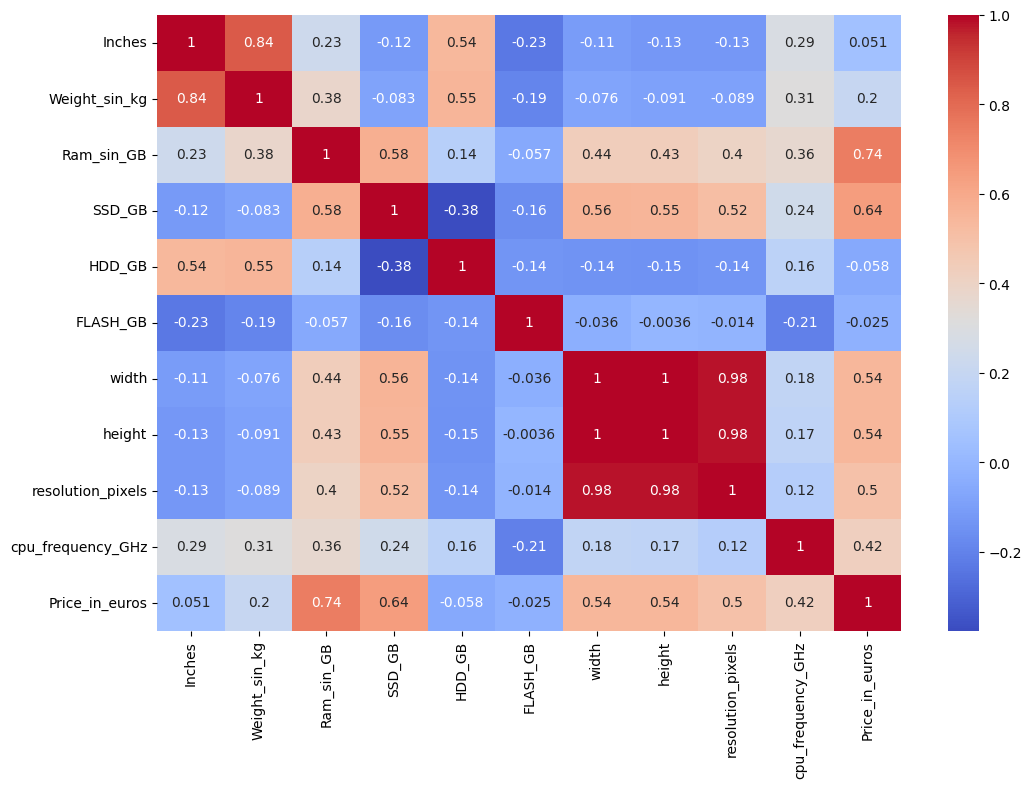

In [147]:
df_corr = pd.concat([X_train[numericas], y_train], axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")
plt.show()

In [148]:
numericas = ['Inches', 'Weight_sin_kg', 'Ram_sin_GB','SSD_GB', 'HDD_GB', 'FLASH_GB','width', 'height', 'resolution_pixels','cpu_frequency_GHz', ]

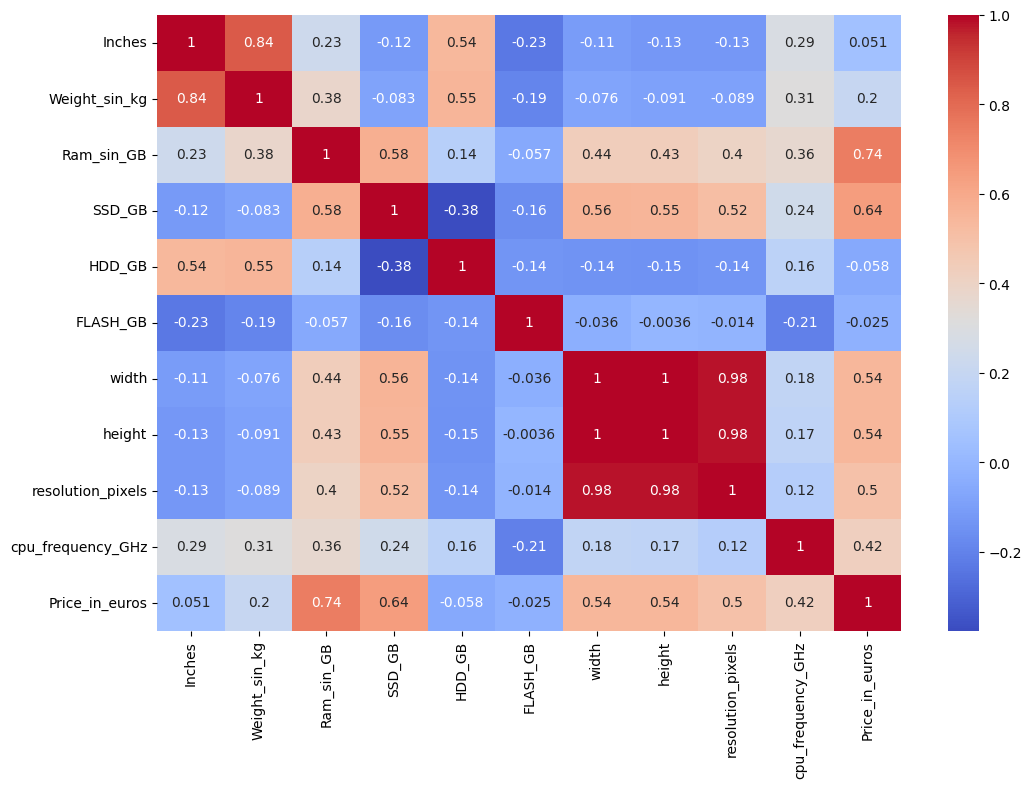

In [149]:
df_corr = pd.concat([X_train[numericas], y_train], axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")
plt.show()

In [150]:
import bootcampviztools as bt

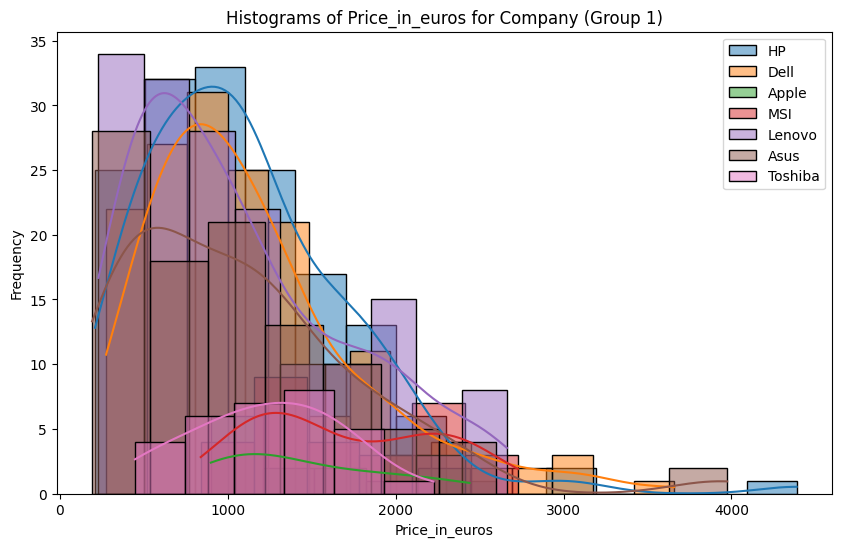

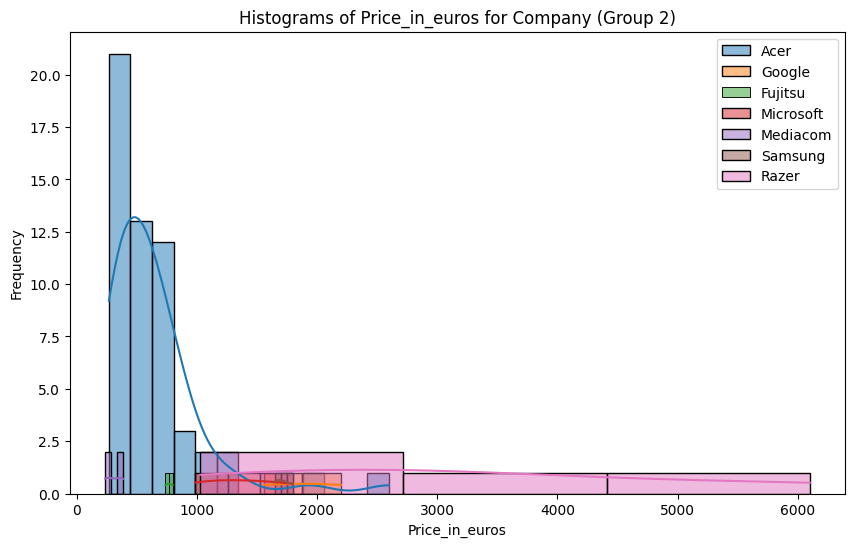

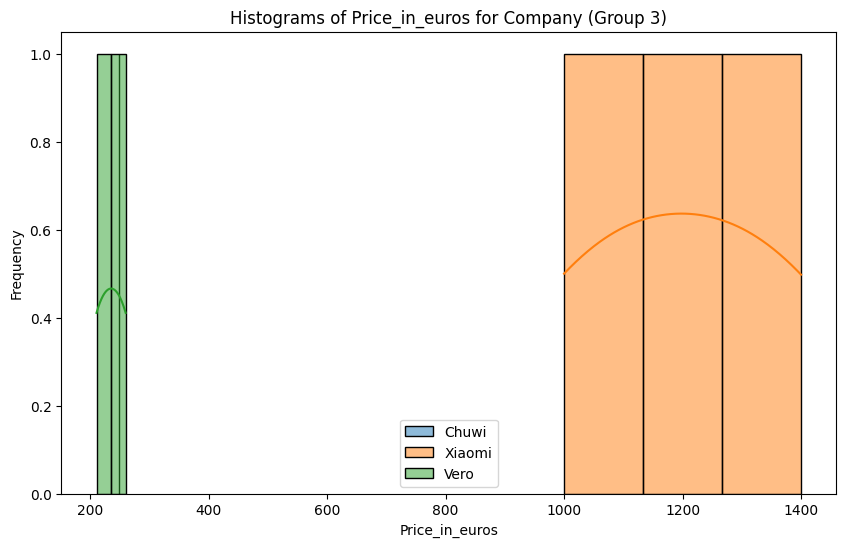

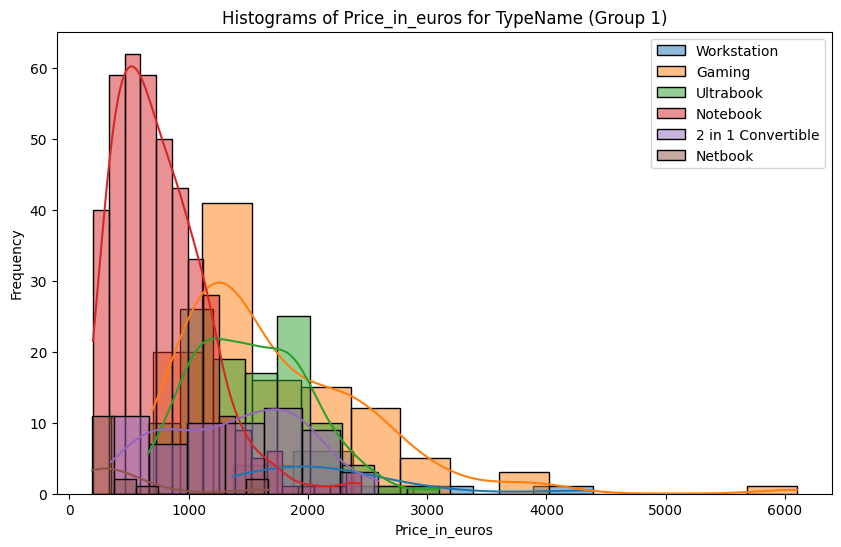

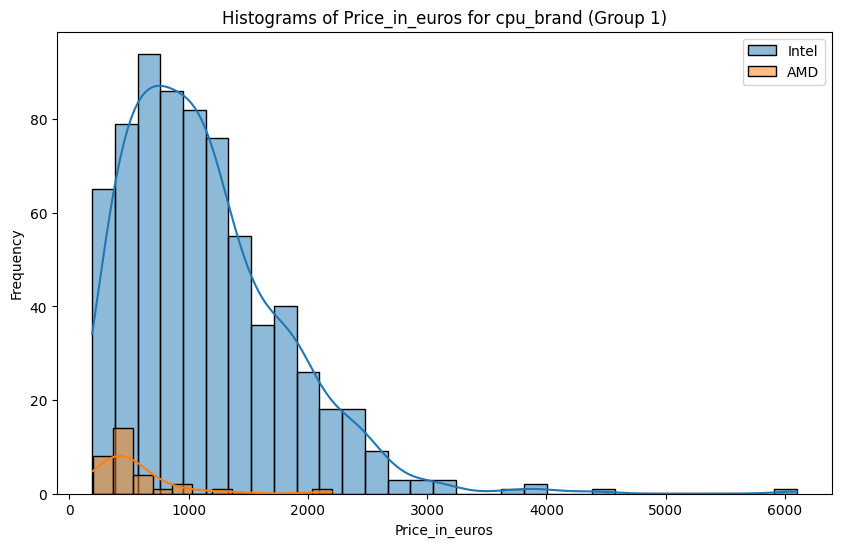

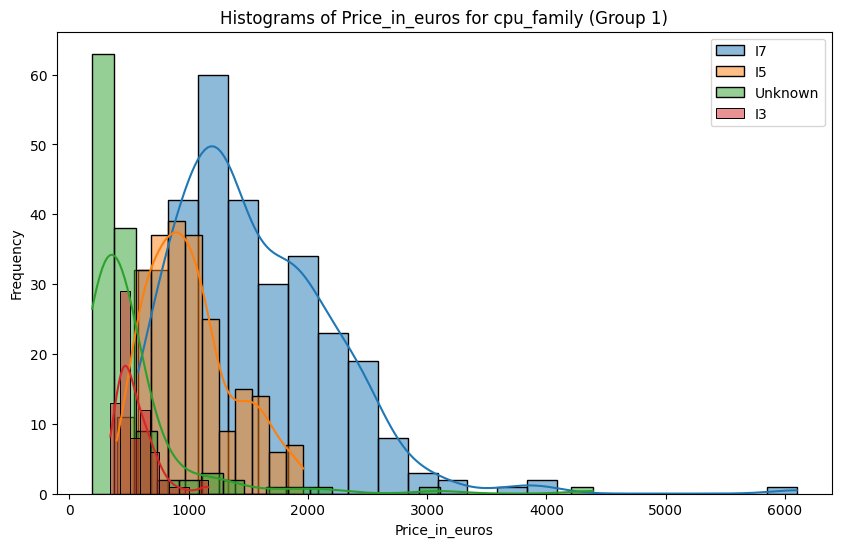

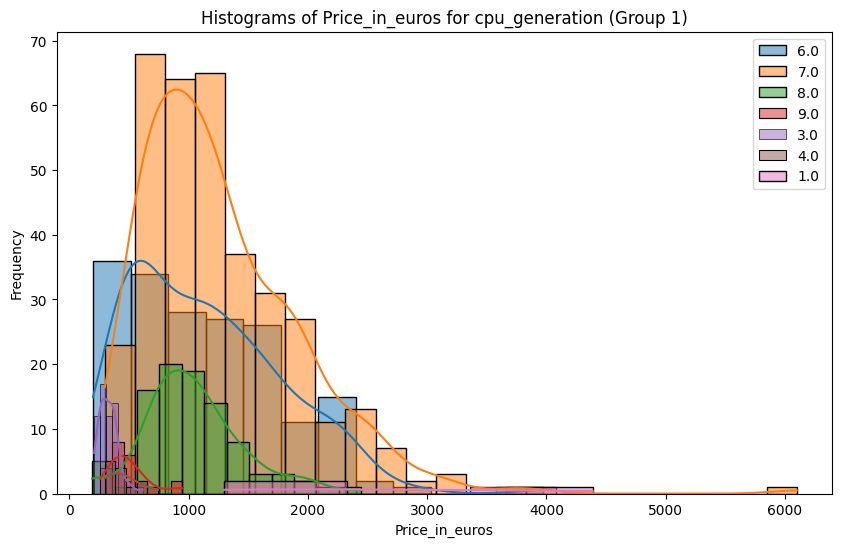

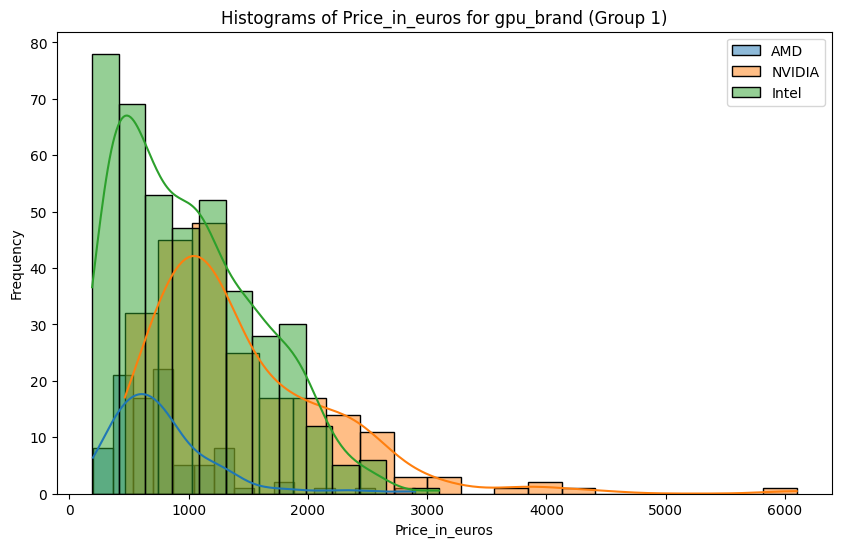

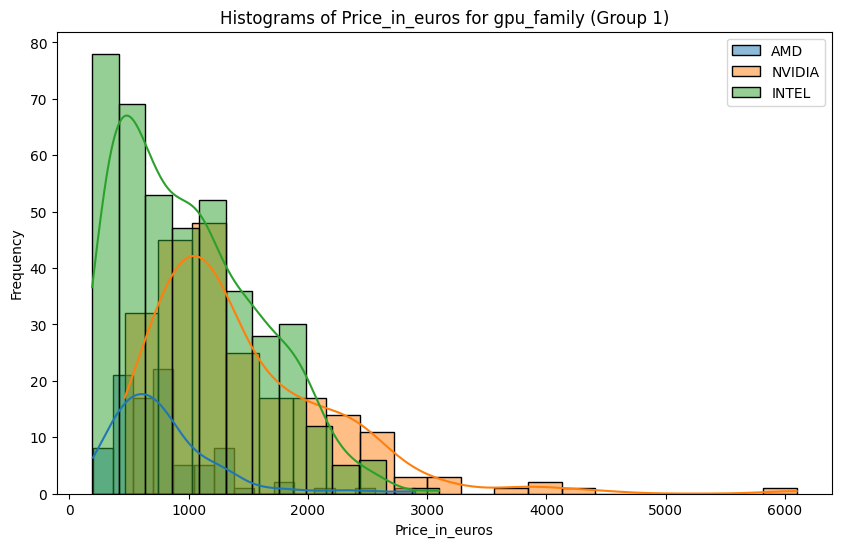

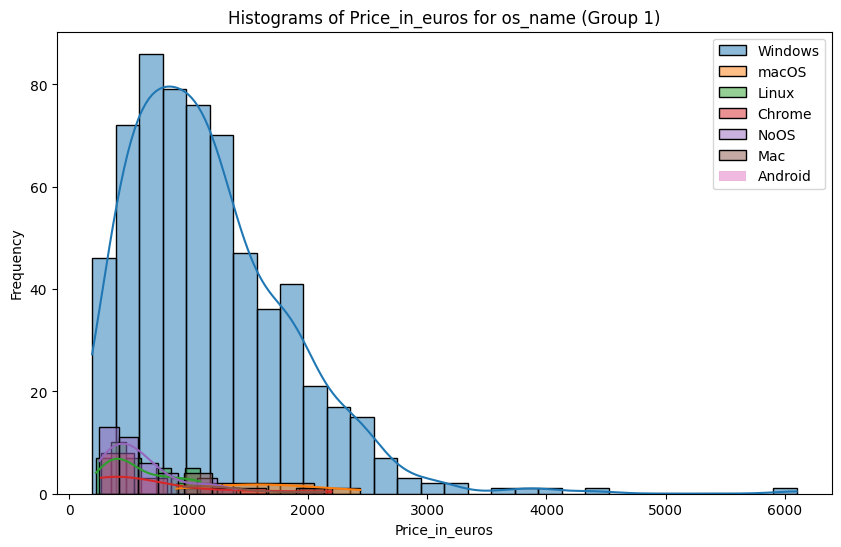

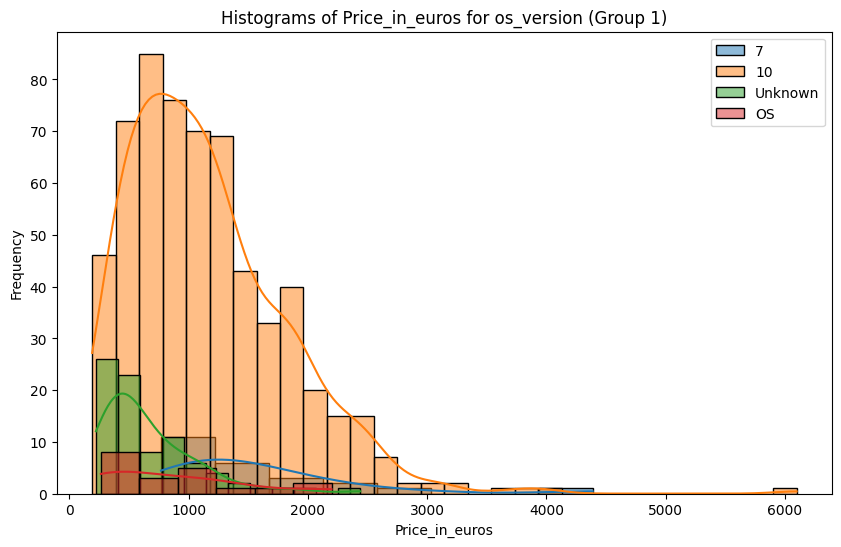

In [151]:
for categorica in categoricas:
    bt.plot_grouped_histograms(pd.concat([X_train[categoricas], y_train], axis=1),cat_col=categorica,num_col="Price_in_euros", group_size=len(categorica) )

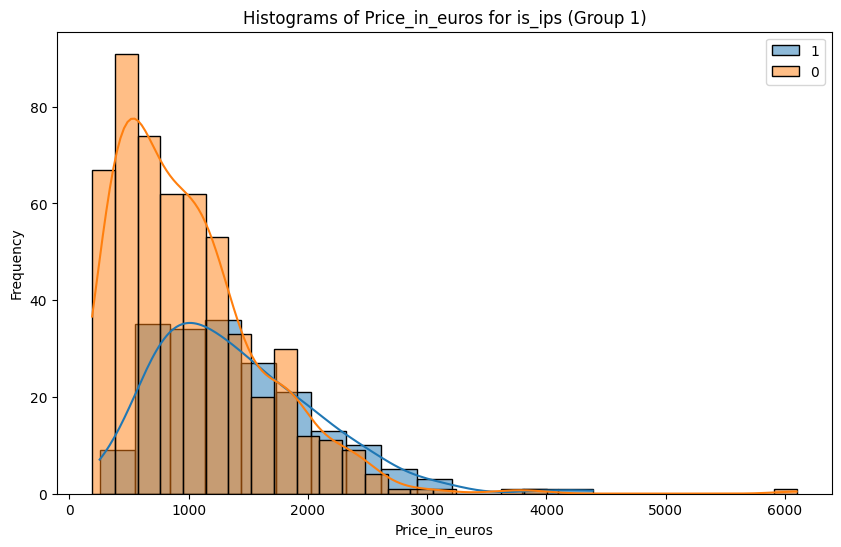

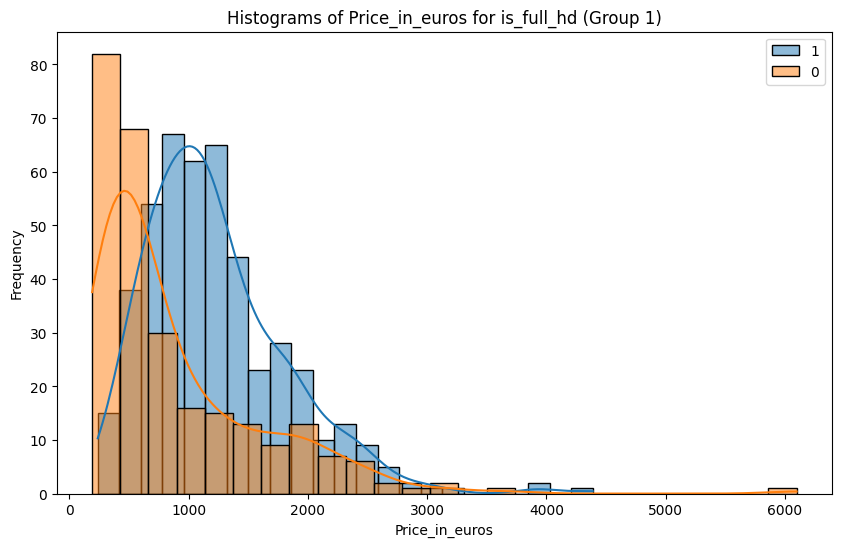

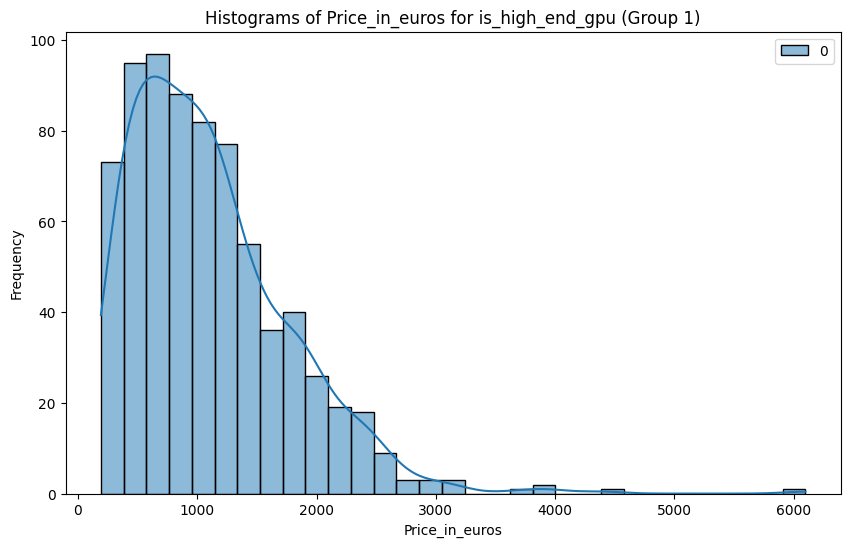

In [152]:
for binaria in binarias:
    bt.plot_grouped_histograms(pd.concat([X_train[binarias], y_train], axis=1),cat_col=binaria,num_col="Price_in_euros", group_size=len(binarias) )

array([[<Axes: title={'center': 'Inches'}>,
        <Axes: title={'center': 'Weight_sin_kg'}>,
        <Axes: title={'center': 'Ram_sin_GB'}>],
       [<Axes: title={'center': 'SSD_GB'}>,
        <Axes: title={'center': 'HDD_GB'}>,
        <Axes: title={'center': 'FLASH_GB'}>],
       [<Axes: title={'center': 'width'}>,
        <Axes: title={'center': 'height'}>,
        <Axes: title={'center': 'resolution_pixels'}>],
       [<Axes: title={'center': 'cpu_frequency_GHz'}>, <Axes: >,
        <Axes: >]], dtype=object)

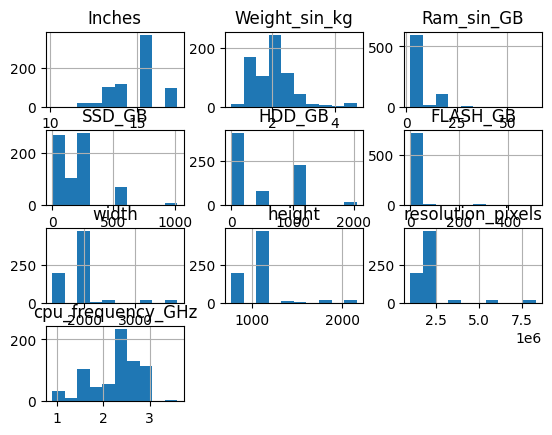

In [153]:
X_train[numericas].hist()

In [154]:
X_train["SSD_GB"].value_counts()

SSD_GB
256     275
0       262
128     102
512      71
1024     10
32        3
180       2
240       1
8         1
16        1
64        1
Name: count, dtype: int64

In [155]:
X_train[categoricas].columns

Index(['Company', 'TypeName', 'cpu_brand', 'cpu_family', 'cpu_generation',
       'gpu_brand', 'gpu_family', 'os_name', 'os_version'],
      dtype='object')

In [156]:
# Aplicar get_dummies
X_train = pd.get_dummies(X_train, columns=categoricas, drop_first=False)
x_test  = pd.get_dummies(X_test, columns=categoricas, drop_first=False)

# Alinear columnas para que train y test tengan exactamente las mismas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [157]:
from sklearn.preprocessing import StandardScaler

In [158]:
escalador = StandardScaler()

In [159]:
X_train[numericas] = escalador.fit_transform(X_train[numericas])

# Transformar test usando el mismo scaler
X_test[numericas] = escalador.transform(X_test[numericas])

In [160]:
X_train

,Inches,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,resolution_pixels,is_ips,...,os_name_Chrome,os_name_Linux,os_name_Mac,os_name_NoOS,os_name_Windows,os_name_macOS,os_version_10,os_version_7,os_version_OS,os_version_Unknown
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,1.608931,1.447238,-0.046800,-0.960684,1.160085,-0.168796,0.067966,0.052725,-0.053975,1,...,False,False,False,False,True,False,False,True,False,False
153,0.418230,0.788210,1.558700,1.780032,-0.807522,-0.168796,0.067966,0.052725,-0.053975,0,...,False,False,False,False,True,False,True,False,False,False
275,-1.192719,-0.994161,-0.046800,1.780032,-0.807522,-0.168796,1.369387,1.900640,1.427786,1,...,False,False,False,False,False,True,False,False,False,True
1100,-0.702430,-0.739537,-0.849549,-0.960684,0.153224,-0.168796,0.067966,0.052725,-0.053975,0,...,False,False,False,False,True,False,False,True,False,False
131,1.608931,1.147680,1.558700,0.409674,3.127693,-0.168796,0.067966,0.052725,-0.053975,0,...,False,False,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,-0.702430,-0.140420,-0.046800,-0.960684,3.127693,-0.168796,-1.058576,-1.056024,-0.804610,0,...,False,False,False,False,True,False,True,False,False,False
996,0.418230,0.249005,-0.448174,0.409674,-0.807522,-0.168796,0.067966,0.052725,-0.053975,0,...,False,False,False,False,True,False,True,False,False,False
770,-1.753048,-1.278742,1.558700,0.409674,-0.807522,-0.168796,0.067966,0.052725,-0.053975,0,...,False,False,False,False,True,False,True,False,False,False


In [161]:
X_test

,Inches,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,resolution_pixels,is_ips,...,os_name_Chrome,os_name_Linux,os_name_Mac,os_name_NoOS,os_name_Windows,os_name_macOS,os_version_10,os_version_7,os_version_OS,os_version_Unknown
laptop_ID,,,,,,,,,,,,,,,,,,,,,
451,0.418230,0.249005,-0.046800,-0.275505,1.160085,-0.168796,0.067966,0.052725,-0.053975,1,...,0,0,0,0,0,0,0,0,0,0
802,0.418230,0.069270,-0.046800,0.409674,-0.807522,-0.168796,0.067966,0.052725,-0.053975,0,...,0,0,0,0,0,0,0,0,0,0
723,-0.702430,-0.245266,-0.046800,0.409674,-0.807522,-0.168796,0.067966,0.052725,-0.053975,1,...,0,0,0,0,0,0,0,0,0,0
682,-0.702430,-0.604736,-0.849549,-0.275505,-0.807522,-0.168796,0.067966,0.052725,-0.053975,1,...,0,0,0,0,0,0,0,0,0,0
1306,0.418230,0.249005,-0.849549,-0.960684,0.153224,-0.168796,-1.058576,-1.056024,-0.804610,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,0.418230,-0.260244,-0.046800,-0.960684,1.160085,-0.168796,0.067966,0.052725,-0.053975,0,...,0,0,0,0,0,0,0,0,0,0
626,-2.383420,-1.173896,-0.849549,-0.960684,-0.807522,0.785099,-1.058576,-1.056024,-0.804610,1,...,0,0,0,0,0,0,0,0,0,0
416,-2.383420,-1.323676,-1.250924,-0.960684,-0.807522,0.785099,-1.058576,-1.056024,-0.804610,0,...,0,0,0,0,0,0,0,0,0,0


In [162]:
X_test[numericas].describe()

,Inches,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,resolution_pixels,cpu_frequency_GHz
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,-0.074355,-0.050864,0.029966,0.133192,-0.115323,-0.069758,-0.035263,-0.014076,-0.029049,0.080002
std,1.028970,0.982462,1.060397,1.184275,0.950282,0.350179,0.940287,0.969285,0.935081,1.004839
min,-3.434038,-2.012659,-1.250924,-0.960684,-0.807522,-0.168796,-1.058576,-1.056024,-0.804610,-2.479587
25%,-0.702430,-0.874338,-0.849549,-0.960684,-0.807522,-0.168796,-1.058576,-1.056024,-0.804610,-0.539541
50%,0.418230,-0.050553,-0.046800,0.409674,-0.807522,-0.168796,0.067966,0.052725,-0.053975,0.430483
75%,0.418230,0.406273,-0.046800,0.409674,1.160085,-0.168796,0.067966,0.052725,-0.053975,0.818492
max,2.379384,3.574102,4.769699,4.520747,3.127693,1.738994,3.972229,3.890703,4.503849,1.788516


In [163]:
X_train[numericas].describe()

,Inches,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,resolution_pixels,cpu_frequency_GHz
count,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02
mean,1.700819e-15,-1.364554e-16,-1.583857e-16,1.949363e-17,-7.553781e-17,-4.386066e-17,-1.242719e-16,-1.340187e-16,1.267086e-16,-5.628785e-16
std,1.000687e+00,1.000687e+00,1.000687e+00,1.000687e+00,1.000687e+00,1.000687e+00,1.000687e+00,1.000687e+00,1.000687e+00,1.000687e+00
min,-3.434038e+00,-2.012659e+00,-1.250924e+00,-9.606838e-01,-8.075220e-01,-1.687963e-01,-1.058576e+00,-1.056024e+00,-8.046098e-01,-2.673592e+00
25%,-7.024300e-01,-7.994486e-01,-8.495493e-01,-9.606838e-01,-8.075220e-01,-1.687963e-01,-9.080993e-01,-5.869378e-01,-6.237035e-01,-9.275499e-01
50%,4.182297e-01,9.358627e-03,-4.679954e-02,-2.755049e-01,-8.075220e-01,-1.687963e-01,6.796644e-02,5.272515e-02,-5.397544e-02,4.304828e-01
75%,4.182297e-01,3.987843e-01,-4.679954e-02,4.096740e-01,1.160085e+00,-1.687963e-01,6.796644e-02,5.272515e-02,-5.397544e-02,8.184922e-01
max,1.608931e+00,3.993483e+00,1.119170e+01,4.520747e+00,3.127693e+00,1.509353e+01,3.972229e+00,3.890703e+00,4.503849e+00,2.564534e+00


In [164]:
X_train.columns

Index(['Inches', 'Weight_sin_kg', 'Ram_sin_GB', 'SSD_GB', 'HDD_GB', 'FLASH_GB',
       'width', 'height', 'resolution_pixels', 'is_ips', 'is_full_hd',
       'cpu_frequency_GHz', 'is_high_end_gpu', 'Company_Acer', 'Company_Apple',
       'Company_Asus', 'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu',
       'Company_Google', 'Company_HP', 'Company_Lenovo', 'Company_MSI',
       'Company_Mediacom', 'Company_Microsoft', 'Company_Razer',
       'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'cpu_brand_AMD', 'cpu_brand_Intel', 'cpu_family_I3', 'cpu_family_I5',
       'cpu_family_I7', 'cpu_family_Unknown', 'cpu_generation_1.0',
       'cpu_generation_3.0', 'cpu_generation_4.0', 'cpu_generation_6.0',
       'cpu_generation_7.0', 'cpu_generation_8.0', 'cpu_generation_9.0',
       'gpu_brand_AMD', 'gpu_brand_I

In [165]:
categoricas = ['Company_Acer', 'Company_Apple', 'Company_Asus', 'Company_Chuwi',
       'Company_Dell', 'Company_Fujitsu', 'Company_Google', 'Company_HP',
       'Company_Lenovo', 'Company_MSI', 'Company_Mediacom',
       'Company_Microsoft', 'Company_Razer', 'Company_Samsung',
       'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'cpu_brand_AMD', 'cpu_brand_Intel', 'cpu_family_I3', 'cpu_family_I5',
       'cpu_family_I7', 'cpu_family_Unknown', 'cpu_generation_1.0',
       'cpu_generation_3.0', 'cpu_generation_4.0', 'cpu_generation_6.0',
       'cpu_generation_7.0', 'cpu_generation_8.0', 'cpu_generation_9.0',
       'gpu_brand_AMD', 'gpu_brand_Intel', 'gpu_brand_NVIDIA',
       'gpu_family_AMD', 'gpu_family_INTEL', 'gpu_family_NVIDIA',
       'os_name_Android', 'os_name_Chrome', 'os_name_Linux', 'os_name_Mac',
       'os_name_NoOS', 'os_name_Windows', 'os_name_macOS', 'os_version_10',
       'os_version_7', 'os_version_OS', 'os_version_Unknown']

In [166]:
features = numericas+categoricas+binarias

In [167]:
len(features )

66

In [168]:
X_test_final = X_test[features]
X_train_final = X_train[features]

In [169]:
X_train_final

,Inches,Weight_sin_kg,Ram_sin_GB,SSD_GB,HDD_GB,FLASH_GB,width,height,resolution_pixels,cpu_frequency_GHz,...,os_name_NoOS,os_name_Windows,os_name_macOS,os_version_10,os_version_7,os_version_OS,os_version_Unknown,is_ips,is_full_hd,is_high_end_gpu
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,1.608931,1.447238,-0.046800,-0.960684,1.160085,-0.168796,0.067966,0.052725,-0.053975,0.624487,...,False,True,False,False,True,False,False,1,1,0
153,0.418230,0.788210,1.558700,1.780032,-0.807522,-0.168796,0.067966,0.052725,-0.053975,1.012497,...,False,True,False,True,False,False,False,0,1,0
275,-1.192719,-0.994161,-0.046800,1.780032,-0.807522,-0.168796,1.369387,1.900640,1.427786,1.206502,...,False,False,True,False,False,False,True,1,0,0
1100,-0.702430,-0.739537,-0.849549,-0.960684,0.153224,-0.168796,0.067966,0.052725,-0.053975,0.042473,...,False,True,False,False,True,False,False,0,1,0
131,1.608931,1.147680,1.558700,0.409674,3.127693,-0.168796,0.067966,0.052725,-0.053975,-0.927550,...,False,True,False,True,False,False,False,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,-0.702430,-0.140420,-0.046800,-0.960684,3.127693,-0.168796,-1.058576,-1.056024,-0.804610,-1.315559,...,False,True,False,True,False,False,False,0,0,0
996,0.418230,0.249005,-0.448174,0.409674,-0.807522,-0.168796,0.067966,0.052725,-0.053975,2.564534,...,False,True,False,True,False,False,False,0,1,0
770,-1.753048,-1.278742,1.558700,0.409674,-0.807522,-0.168796,0.067966,0.052725,-0.053975,1.012497,...,False,True,False,True,False,False,False,0,1,0


-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [170]:
rf = RandomForestRegressor(max_depth=10,random_state=42)

In [171]:
rf.fit(X_train_final,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [172]:
root_mean_squared_error(y_test,((rf.predict(X_test_final))))

437.27946790180306

### 4.3 Optimización (up to you 🫰🏻)

In [173]:
from sklearn.model_selection import GridSearchCV

In [174]:
rf_param_grid = {
    "n_estimators": [400, 700, 1000],
    "max_depth": [None, 20, 10, 5, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train_final, y_train)

Fitting 3 folds for each of 135 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [400, 700, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [175]:
rf_grid.best_params_

{'max_depth': 15,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 700}

In [176]:
rf_f = RandomForestRegressor(**rf_grid.best_params_)

In [177]:
rf_f.fit(X_train_final,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [178]:
root_mean_squared_error(y_test,((rf_f.predict(X_test_final))))

445.43637793528256

In [179]:
from xgboost import XGBRegressor

In [180]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_param_grid = {
    "n_estimators": [600, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5,7, 9],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 2]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 5, ...], 'n_estimators': [600, 1000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [181]:
xgb_f = XGBRegressor(**xgb_grid.best_params_)

In [182]:
xgb_f.fit(X_train_final,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [183]:
root_mean_squared_error(y_test,(xgb_f.predict(X_test_final)))

419.96007221022404

In [184]:
from sklearn.metrics import mean_absolute_percentage_error

In [185]:
mean_absolute_percentage_error(y_test,(xgb_f.predict(X_test_final)))

0.3252685190350413

In [186]:
y_train.describe()

count     729.000000
mean     1103.789314
std       672.778174
min       191.900000
25%       598.000000
50%       985.000000
75%      1460.000000
max      6099.000000
Name: Price_in_euros, dtype: float64

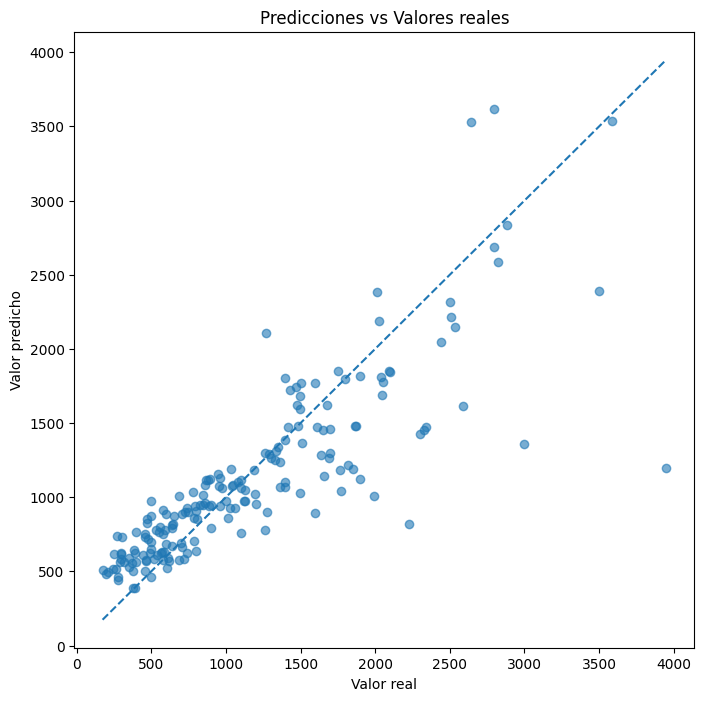

In [115]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener predicciones
y_pred = xgb_f.predict(X_test_final)

# Crear figura
plt.figure(figsize=(8, 8))

# Scatter
plt.scatter(y_test, (y_pred), alpha=0.6)

# Línea perfecta (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Predicciones vs Valores reales")
plt.show()


-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [223]:
X_pred = pd.read_csv("./data/test.csv", index_col="laptop_ID")
X_pred.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [224]:
X_pred.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [225]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 209 to 421
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           391 non-null    object 
 1   Product           391 non-null    object 
 2   TypeName          391 non-null    object 
 3   Inches            391 non-null    float64
 4   ScreenResolution  391 non-null    object 
 5   Cpu               391 non-null    object 
 6   Ram               391 non-null    object 
 7   Memory            391 non-null    object 
 8   Gpu               391 non-null    object 
 9   OpSys             391 non-null    object 
 10  Weight            391 non-null    object 
dtypes: float64(1), object(10)
memory usage: 36.7+ KB


 ## 2. Replicar el procesado para ``test.csv``

In [226]:
X_pred

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg
...,...,...,...,...,...,...,...,...,...,...,...
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg


In [227]:
X_pred["Weight_sin_kg"]= X_pred["Weight"].str.replace("kg","").astype(float)
X_pred["Ram_sin_GB"]= X_pred["Ram"].str.replace("GB","").astype(int)


In [228]:
predictions_submit = rf.predict(X_pred[features])
predictions_submit

KeyError: "['SSD_GB', 'resolution_pixels', 'cpu_frequency_GHz', 'HDD_GB', 'FLASH_GB', 'Company_Acer', 'Company_Apple', 'Company_Asus', 'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google', 'Company_HP', 'Company_Lenovo', 'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer', 'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi', 'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation', 'cpu_brand_AMD', 'cpu_brand_Intel', 'cpu_family_I3', 'cpu_family_I5', 'cpu_family_I7', 'cpu_family_Unknown', 'cpu_generation_1.0', 'cpu_generation_3.0', 'cpu_generation_4.0', 'cpu_generation_6.0', 'cpu_generation_7.0', 'cpu_generation_8.0', 'cpu_generation_9.0', 'gpu_brand_AMD', 'gpu_brand_Intel', 'gpu_brand_NVIDIA', 'gpu_family_AMD', 'gpu_family_INTEL', 'gpu_family_NVIDIA', 'os_name_Android', 'os_name_Chrome', 'os_name_Linux', 'os_name_Mac', 'os_name_NoOS', 'os_name_Windows', 'os_name_macOS', 'os_version_10', 'os_version_7', 'os_version_OS', 'os_version_Unknown', 'is_ips', 'is_full_hd'] not in index"

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [ ]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [ ]:
sample = pd.read_csv("data/sample_submission.csv")

In [ ]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [ ]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [ ]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({"laptop_ID":X_pred.index,"Price_in_euros":predictions_submit})

In [ ]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1552.354340
1,1281,558.034890
2,1168,511.416332
3,1231,903.091414
4,1020,767.025303


In [ ]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [ ]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [ ]:
chequeador(submission)

You're ready to submit!
